In [138]:
import importlib
import brazilien_ecommerce.cleaning as cleaning

importlib.reload(cleaning)


<module 'brazilien_ecommerce.cleaning' from 'C:\\Full_stack\\Portfolios\\Projets\\Data_Analysis_Projects\\Marketing\\Brazilien_ecommerce\\src\\brazilien_ecommerce\\cleaning.py'>

In [139]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from brazilien_ecommerce.cleaning import (
    normalize_city,
    normalize_city_v2,
    remove_state_suffix 
)


In [140]:
# %pip install Kagglehub

In [141]:
customers_df = pd.read_csv(r"..\data\bronze\olist_customers_dataset.csv")
customers_df.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [142]:
customers_df.shape

(99441, 5)

In [143]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [144]:
customers_df.loc[: , ['customer_id' , 'customer_unique_id']].duplicated().sum()

np.int64(0)

In [145]:
customers_df['customer_state'].unique()

<ArrowStringArray>
['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA', 'MS', 'CE',
 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB', 'TO', 'PI', 'AC', 'SE',
 'RR']
Length: 27, dtype: str

In [146]:
pd.set_option("Display.max_rows" , 999)
pd.set_option("Display.max_columns", 999)


In [147]:
customers_df["customer_city"].value_counts()[
    customers_df["customer_city"].value_counts()  < 10
].sort_index().to_dict()


{'abadia dos dourados': 3,
 'abadiania': 1,
 'abaiara': 2,
 'abaira': 2,
 'abare': 2,
 'abatia': 3,
 'abdon batista': 1,
 'abelardo luz': 6,
 'abrantes': 2,
 'abre campo': 6,
 'acaiaca': 2,
 'acailandia': 7,
 'acajutiba': 1,
 'acarau': 8,
 'acari': 1,
 'acegua': 2,
 'acopiara': 7,
 'acreuna': 7,
 'acu': 3,
 'acucena': 1,
 'adhemar de barros': 1,
 'adolfo': 5,
 'adrianopolis': 1,
 'adustina': 1,
 'afogados da ingazeira': 8,
 'afranio': 2,
 'agisse': 1,
 'agrestina': 1,
 'agrolandia': 1,
 'agronomica': 2,
 'agua branca': 5,
 'agua clara': 2,
 'agua comprida': 2,
 'agua doce': 1,
 'agua doce do norte': 4,
 'agua fria de goias': 1,
 'agua limpa': 1,
 'agua nova': 1,
 'agua preta': 1,
 'agua santa': 2,
 'aguas belas': 6,
 'aguas claras': 1,
 'aguas de santa barbara': 3,
 'aguas de sao pedro': 3,
 'aguas formosas': 5,
 'aguas frias': 1,
 'aguas mornas': 1,
 'aguas vermelhas': 3,
 'agudo': 1,
 'aguia branca': 2,
 'aiuaba': 1,
 'aiuruoca': 4,
 'ajapi': 1,
 'ajuricaba': 2,
 'alagoa': 1,
 'alago

In [148]:

customers_df["customer_city_clean"] = customers_df["customer_city"].astype(str).apply(normalize_city)


In [149]:
customers_df["customer_city_clean"].value_counts()[
    customers_df["customer_city_clean"].value_counts() < 10
].sort_index().to_dict()


{'abadia dos dourados': 3,
 'abadiania': 1,
 'abaiara': 2,
 'abaira': 2,
 'abare': 2,
 'abatia': 3,
 'abdon batista': 1,
 'abelardo luz': 6,
 'abrantes': 2,
 'abre campo': 6,
 'acaiaca': 2,
 'acailandia': 7,
 'acajutiba': 1,
 'acarau': 8,
 'acari': 1,
 'acegua': 2,
 'acopiara': 7,
 'acreuna': 7,
 'acu': 3,
 'acucena': 1,
 'adhemar de barros': 1,
 'adolfo': 5,
 'adrianopolis': 1,
 'adustina': 1,
 'afogados da ingazeira': 8,
 'afranio': 2,
 'agisse': 1,
 'agrestina': 1,
 'agrolandia': 1,
 'agronomica': 2,
 'agua branca': 5,
 'agua clara': 2,
 'agua comprida': 2,
 'agua doce': 1,
 'agua doce do norte': 4,
 'agua fria de goias': 1,
 'agua limpa': 1,
 'agua nova': 1,
 'agua preta': 1,
 'agua santa': 2,
 'aguas belas': 6,
 'aguas claras': 1,
 'aguas de santa barbara': 3,
 'aguas de sao pedro': 3,
 'aguas formosas': 5,
 'aguas frias': 1,
 'aguas mornas': 1,
 'aguas vermelhas': 3,
 'agudo': 1,
 'aguia branca': 2,
 'aiuaba': 1,
 'aiuruoca': 4,
 'ajapi': 1,
 'ajuricaba': 2,
 'alagoa': 1,
 'alago

In [150]:
geolocalisation_df = pd.read_csv(r"..\data\bronze\olist_geolocation_dataset.csv")

In [151]:
geolocalisation_df.head(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [152]:
geol_state = geolocalisation_df["geolocation_state"].unique()

In [153]:
custom_state = customers_df["customer_state"]

In [154]:
list(set(custom_state) -  set(geol_state))

[]

In [155]:
order_items_df = pd.read_csv(r"..\data\bronze\olist_order_items_dataset.csv")

In [156]:
len(order_items_df["order_id"].unique()) , order_items_df.shape[0]

(98666, 112650)

In [157]:
order_items_df["order_id"].duplicated().sum()

np.int64(13984)

In [158]:
order_items_df.iloc[order_items_df.loc[:, ["order_id", "seller_id" , "product_id"]].duplicated(), :]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
43,001ab0a7578dd66cd4b0a71f5b6e1e41,2,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63
44,001ab0a7578dd66cd4b0a71f5b6e1e41,3,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63
...,...,...,...,...,...,...,...
112617,ffecd5a79a0084f6a592288c67e3c298,3,50fd2b788dc166edd20512370dac54df,8b321bb669392f5163d04c59e235e066,2018-03-05 20:15:27,21.90,15.79
112635,fff8287bbae429a99bb7e8c21d151c41,2,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19


In [159]:
order_id = "0008288aa423d2a3f00fcb17cd7d8719"
order_items_df.loc[order_items_df["order_id"].eq(order_id)]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.9,13.37
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.9,13.37


In [160]:
order_items_df.loc[ : , ['order_id','order_item_id']].duplicated().sum

<bound method Series.sum of 0         False
1         False
2         False
3         False
4         False
          ...  
112645    False
112646    False
112647    False
112648    False
112649    False
Length: 112650, dtype: bool>

<Axes: >

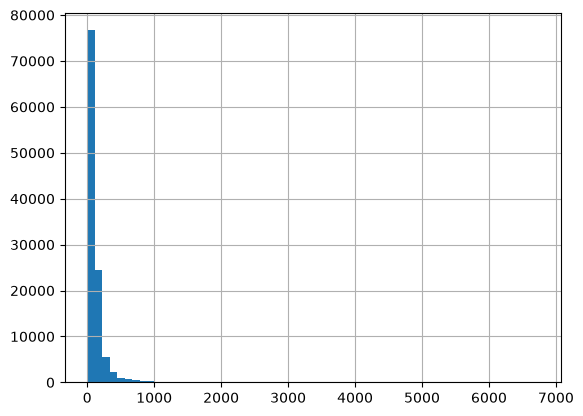

In [161]:
order_items_df['price'].hist(bins=60)

In [162]:
order_items_df['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

<Axes: >

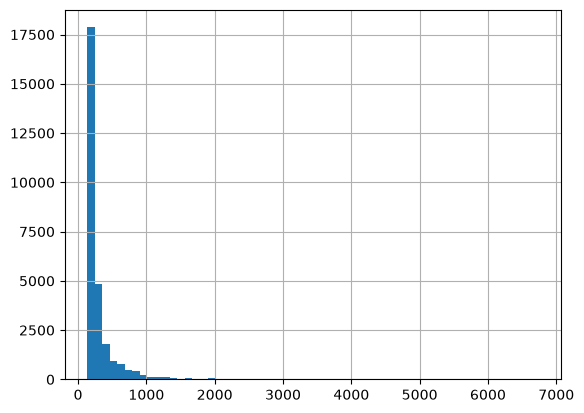

In [163]:
(order_items_df["price"]).describe(percentiles=[0, 0.75, 0.8, 0.9, 0.99])

q3 = order_items_df["price"].quantile(0.75)

order_items_df.iloc[order_items_df["price"] > q3]["price"].hist(bins=60)


In [ ]:
order_items_df.nlargest(20, "price")[["order_id", "product_id", "seller_id", "price"]]


,order_id,product_id,seller_id,price
3556,0812eb902a67711a1cb742b3cdaa65ae,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,6735.00
112233,fefacc66af859508bf1a7934eab1e97f,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,6729.00
107841,f5136e38d1a14a4dbd87dff67da82701,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,6499.00
74336,a96610ab360d42a2e5335a3998b4718a,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,4799.00
11249,199af31afc78c699f0dbf71fb178d4d4,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,4690.00
62086,8dbc85d1447242f3b127dda390d56e19,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,4590.00
29193,426a9742b533fc6fed17d1fd6d143d7e,a1beef8f3992dbd4cd8726796aa69c53,512d298ac2a96d1931b6bd30aa21f61d,4399.87
45843,68101694e5c5dc7330c91e1bbc36214f,6cdf8fc1d741c76586d8b6b15e9eef30,ed4acab38528488b65a9a9c603ff024a,4099.99
78310,b239ca7cd485940b31882363b52e6674,dd113cb02b2af9c8e5787e8f1f0722f6,821fb029fc6e495ca4f08a35d51e53a5,4059.00
59137,86c4eab1571921a6a6e248ed312f5a5a,6902c1962dd19d540807d0ab8fade5c6,fa1c13f2614d7b5c4749cbc52fecda94,3999.90


In [165]:
order_payement_df = pd.read_csv(r"..\data\bronze\olist_order_payments_dataset.csv")
order_payement_df.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [166]:
print(order_payement_df.shape)

(103886, 5)


In [167]:
order_payement_df.duplicated().sum()

np.int64(0)

In [168]:
order_payement_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB


In [169]:
order_df = pd.read_csv(r"..\data\bronze\olist_orders_dataset.csv")
order_df.shape

(99441, 8)

In [170]:
order_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [171]:
date_cols = order_df.columns.difference(["order_id", "customer_id", "order_status"])
cols = order_df.columns
for col in date_cols:
    order_df[col] = pd.to_datetime(order_df[col] , errors ="coerce" )


In [172]:
order_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 13.0 MB


In [173]:
order_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [174]:
all_no_date = order_df.iloc[order_df.isna().sum(axis=1) >= 3, :]

<Axes: >

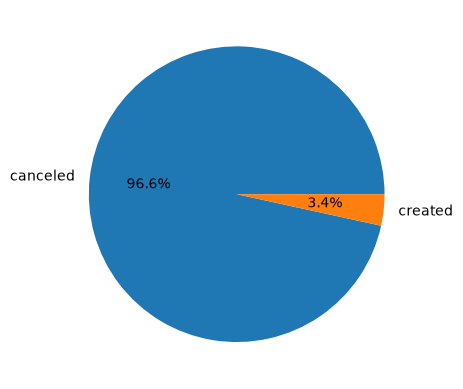

In [175]:
all_no_date["order_status"].value_counts().plot(kind="pie", autopct="%1.1f%%")


In [176]:
order_df.duplicated().sum()

np.int64(0)

In [177]:
order_df['order_status'].unique()

<ArrowStringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str

In [178]:
any_date_missing = order_df.iloc[order_df.isna().sum(axis=1) >= 1 , :]

In [179]:
any_date_missing

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


<Axes: xlabel='order_status'>

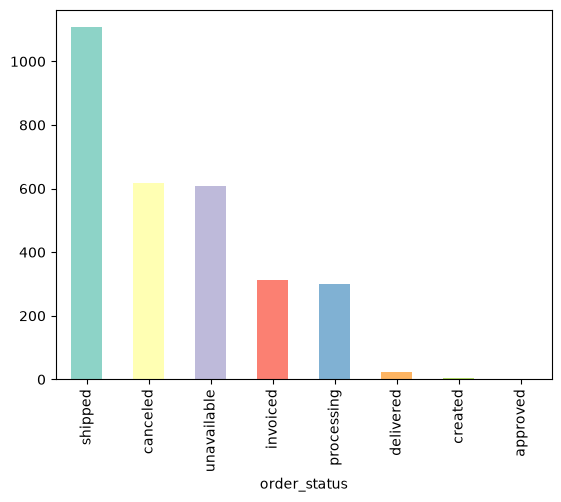

In [180]:
counts = any_date_missing["order_status"].value_counts()

counts.plot(kind="bar", color=sns.color_palette("Set3", n_colors=len(counts)))


In [181]:
(
    order_df["order_delivered_customer_date"] < order_df["order_delivered_carrier_date"] 
)

0        False
1        False
2        False
3        False
4        False
         ...  
99436    False
99437    False
99438    False
99439    False
99440    False
Length: 99441, dtype: bool

In [182]:
order_df["invalid_approved_date"] = (
    order_df["order_approved_at"] < order_df["order_purchase_timestamp"]
)

order_df["invalid_carrier_date"] = (
    order_df["order_delivered_carrier_date"] < order_df["order_approved_at"]
)

order_df["invalid_customer_date"] = (
    order_df["order_delivered_customer_date"] < order_df["order_delivered_carrier_date"]
)


order_df[
    ["invalid_approved_date", "invalid_carrier_date", "invalid_customer_date"]
].sum()

invalid_approved_date       0
invalid_carrier_date     1359
invalid_customer_date      23
dtype: int64

In [183]:
invalid_carrier = order_df.loc[
    order_df["order_delivered_carrier_date"] < order_df["order_approved_at"],
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
    ],
]

invalid_carrier.head(20)


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
15,dcb36b511fcac050b97cd5c05de84dc3,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32
64,688052146432ef8253587b930b01a06d,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58
199,58d4c4747ee059eeeb865b349b41f53a,delivered,2018-07-21 12:49:32,2018-07-26 23:31:53,2018-07-24 12:57:00,2018-07-25 23:58:19
210,412fccb2b44a99b36714bca3fef8ad7b,delivered,2018-07-22 22:30:05,2018-07-23 12:31:53,2018-07-23 12:24:00,2018-07-24 19:26:42
415,56a4ac10a4a8f2ba7693523bb439eede,delivered,2018-07-22 13:04:47,2018-07-27 23:31:09,2018-07-24 14:03:00,2018-07-28 00:05:39
481,32e4fa9bb468884309b58b9348de70c3,delivered,2018-07-04 16:49:21,2018-07-05 16:33:06,2018-07-05 14:50:00,2018-07-07 14:41:18
483,4df92d82d79c3b52c7138679fa9b07fc,delivered,2018-07-24 11:32:11,2018-07-29 23:30:52,2018-07-26 14:46:00,2018-07-27 18:55:57
585,16e38caa92e342c7780f68832f832d4d,delivered,2018-05-07 01:09:09,2018-05-07 16:52:39,2018-05-07 15:09:00,2018-05-24 00:31:18
615,b9afddbdcfadc9a87b41a83271c3e888,delivered,2018-08-16 13:50:48,2018-08-16 14:05:13,2018-08-16 13:27:00,2018-08-24 14:58:37
817,6051e6d3da9a50b7325cbe9c81025062,delivered,2018-07-03 23:40:16,2018-07-05 16:31:26,2018-07-04 12:14:00,2018-07-05 22:52:28


In [184]:
invalid_carrier["delta_carrier_approval"] = (
    invalid_carrier["order_delivered_carrier_date"]
    - invalid_carrier["order_approved_at"]
)

invalid_carrier["delta_carrier_approval"].describe()


count                        1359
mean     -2 days +23:14:52.846947
std        4 days 19:18:28.055754
min           -172 days +18:44:38
25%             -2 days +22:02:36
50%             -1 days +06:49:56
75%      -1 days +22:35:04.500000
max             -1 days +23:59:39
Name: delta_carrier_approval, dtype: object

In [185]:
invalid_carrier["delta_hours"] = (
    invalid_carrier["delta_carrier_approval"].dt.total_seconds() / 3600
)

invalid_carrier["delta_hours"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])


count    1359.000000
mean      -24.751987
std       115.307793
min     -4109.256111
50%       -17.167778
90%        -0.542222
95%        -0.286056
99%        -0.070783
max        -0.005833
Name: delta_hours, dtype: float64

In [186]:
invalid_carrier.sort_values("delta_hours").head(6)


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,delta_carrier_approval,delta_hours
25883,7c48bb55e8e4f7e56d412e9653db37bc,delivered,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,-172 days +18:44:38,-4109.256111
14562,1fab4ac9d85079b3da72a11475ae1685,delivered,2017-09-01 19:04:22,2017-09-13 22:06:11,2017-09-04 13:10:23,2017-09-08 20:13:03,-10 days +15:04:12,-224.930000
46163,0184d4ddb259e1a4cfc2871888cf97b8,delivered,2017-09-01 20:04:28,2017-09-13 22:17:15,2017-09-04 14:05:50,2017-09-09 15:12:44,-10 days +15:48:35,-224.190278
98710,1378f9601350615613cc8832d6789c5d,delivered,2017-09-01 20:28:02,2017-09-13 22:03:51,2017-09-04 18:07:55,2017-09-13 22:24:46,-10 days +20:04:04,-219.932222
41592,8554cb37f7158cb0b082a841d24a4589,delivered,2017-09-01 18:40:44,2017-09-13 21:58:04,2017-09-04 19:12:19,2017-09-08 20:07:45,-10 days +21:14:15,-218.762500
11738,cf72398d0690f841271b695bbfda82d2,delivered,2017-09-01 18:45:33,2017-09-13 22:04:39,2017-09-04 20:12:41,2017-09-11 14:15:02,-10 days +22:08:02,-217.866111


In [187]:
def classify_delay(hours):
    if hours >= -1:
        return "Less than 1h"
    elif hours >= -24:
        return "1h to 24h"
    elif hours >= -72:
        return "1d to 3d"
    else:
        return "More than 3d"


invalid_carrier["anomaly_group"] = invalid_carrier["delta_hours"].apply(classify_delay)

invalid_carrier["anomaly_group"].value_counts()


anomaly_group
1h to 24h       659
1d to 3d        363
Less than 1h    242
More than 3d     95
Name: count, dtype: int64

In [188]:
invalid_carrier["purchase_year"] = invalid_carrier["order_purchase_timestamp"].dt.year

invalid_carrier["purchase_month"] = invalid_carrier[
    "order_purchase_timestamp"
].dt.to_period("M")

invalid_carrier["purchase_month"].value_counts().sort_index()


purchase_month
2017-02      1
2017-04     24
2017-05     14
2017-06      4
2017-07     21
2017-08      1
2017-09     13
2017-11      1
2017-12      5
2018-01     25
2018-02     12
2018-03      2
2018-04    393
2018-05     68
2018-06    123
2018-07    566
2018-08     86
Freq: M, Name: count, dtype: int64

In [189]:
order_df["purchase_month"] = order_df["order_purchase_timestamp"].dt.to_period("M")

monthly_total = order_df.groupby("purchase_month").size()

monthly_invalid = (
    order_df.loc[order_df["invalid_carrier_date"]].groupby("purchase_month").size()
)

monthly_quality = pd.DataFrame(
    {"total_orders": monthly_total, "invalid_carrier": monthly_invalid}
).fillna(0)

monthly_quality["invalid_rate"] = (
    monthly_quality["invalid_carrier"] / monthly_quality["total_orders"] * 100
)

monthly_quality


,total_orders,invalid_carrier,invalid_rate
purchase_month,,,
2016-09,4,0.0,0.000000
2016-10,324,0.0,0.000000
2016-12,1,0.0,0.000000
2017-01,800,0.0,0.000000
2017-02,1780,1.0,0.056180
2017-03,2682,0.0,0.000000
2017-04,2404,24.0,0.998336
2017-05,3700,14.0,0.378378
2017-06,3245,4.0,0.123267


In [190]:
tmp = order_df.loc[
    order_df["invalid_carrier_date"],
    ["purchase_month", "order_approved_at", "order_delivered_carrier_date"],
].copy()

tmp["delta_hours"] = (
    tmp["order_delivered_carrier_date"] - tmp["order_approved_at"]
).dt.total_seconds() / 3600

tmp.groupby("purchase_month")["delta_hours"].agg(
    ["count", "mean", "median", "min", "max"]
)


,count,mean,median,min,max
purchase_month,,,,,
2017-02,1,-162.771389,-162.771389,-162.771389,-162.771389
2017-04,24,-7.151875,-2.735139,-27.825000,-0.083333
2017-05,14,-30.794683,-12.993472,-126.955278,-0.025833
2017-06,4,-106.341458,-116.575139,-192.100556,-0.115000
2017-07,21,-23.628426,-17.167778,-102.064444,-10.345000
2017-08,1,-39.012500,-39.012500,-39.012500,-39.012500
2017-09,13,-198.569765,-217.181667,-224.930000,-53.035278
2017-11,1,-121.339167,-121.339167,-121.339167,-121.339167
2017-12,5,-12.226111,-12.199722,-13.531944,-11.048056


In [191]:
pd.crosstab(
    order_df.loc[order_df["invalid_carrier_date"], "purchase_month"],
    order_df.loc[order_df["invalid_carrier_date"], "order_status"],
)


order_status,delivered,shipped
purchase_month,,
2017-02,1,0
2017-04,24,0
2017-05,14,0
2017-06,4,0
2017-07,20,1
2017-08,1,0
2017-09,13,0
2017-11,1,0
2017-12,5,0


In [192]:
delta_hours = (
    order_df["order_delivered_carrier_date"] - order_df["order_approved_at"]
).dt.total_seconds() / 3600

order_df["carrier_issue_level"] = pd.cut(
    delta_hours,
    bins=[-float("inf"), -72, -24, -1, 0, float("inf")],
    labels=[
        "critical_<-72h",
        "major_-72h_-24h",
        "moderate_-24h_-1h",
        "minor_-1h_0h",
        "valid",
    ],
)


In [193]:
order_df.loc[order_df["invalid_carrier_date"], "carrier_issue_level"].value_counts()


carrier_issue_level
moderate_-24h_-1h    659
major_-72h_-24h      363
minor_-1h_0h         242
critical_<-72h        95
valid                  0
Name: count, dtype: int64

In [194]:
pd.crosstab(
    order_df.loc[order_df["invalid_carrier_date"], "purchase_month"],
    order_df.loc[order_df["invalid_carrier_date"], "carrier_issue_level"],
)


carrier_issue_level,critical_<-72h,major_-72h_-24h,moderate_-24h_-1h,minor_-1h_0h
purchase_month,,,,
2017-02,1,0,0,0
2017-04,0,3,15,6
2017-05,2,4,5,3
2017-06,3,0,0,1
2017-07,1,2,18,0
2017-08,0,1,0,0
2017-09,12,1,0,0
2017-11,1,0,0,0
2017-12,0,0,5,0


In [195]:
order_df["dq_invalid_carrier_date"] = (
    order_df["order_delivered_carrier_date"] < order_df["order_approved_at"]
)


In [196]:
order_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,invalid_approved_date,invalid_carrier_date,invalid_customer_date,purchase_month,carrier_issue_level,dq_invalid_carrier_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False,False,2017-10,valid,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False,False,2018-07,valid,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False,False,2018-08,valid,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,False,False,2017-11,valid,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,False,False,2018-02,valid,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,False,False,False,2017-03,valid,False
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,False,False,False,2018-02,valid,False
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,False,False,False,2017-08,valid,False
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,False,False,False,2018-01,valid,False


Les incohérences entre order_approved_at et order_delivered_carrier_date semblent être un problème de qualité du système source ou du processus d’enregistrement des timestamps. Elles sont concentrées dans certaines périodes, principalement en 2018, et touchent surtout des commandes effectivement livrées.

In [197]:
order_df["carrier_issue_level"] = pd.cut(
    (
        order_df["order_delivered_carrier_date"] - order_df["order_approved_at"]
    ).dt.total_seconds()
    / 3600,
    bins=[-float("inf"), -72, -24, -1, 0, float("inf")],
    labels=[
        "critical_<-72h",
        "major_-72h_-24h",
        "moderate_-24h_-1h",
        "minor_-1h_0h",
        "valid",
    ],
)


In [198]:
order_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,invalid_approved_date,invalid_carrier_date,invalid_customer_date,purchase_month,carrier_issue_level,dq_invalid_carrier_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False,False,2017-10,valid,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False,False,2018-07,valid,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False,False,2018-08,valid,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,False,False,2017-11,valid,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,False,False,2018-02,valid,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,False,False,False,2017-03,valid,False
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,False,False,False,2018-02,valid,False
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,False,False,False,2017-08,valid,False
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,False,False,False,2018-01,valid,False


In [199]:
invalid_customer_date = order_df.loc[order_df["invalid_customer_date"]].copy()

invalid_customer_date["diff"] = (
    invalid_customer_date["order_delivered_customer_date"]
    - invalid_customer_date["order_delivered_carrier_date"]
)

invalid_customer_date["diff"].describe()


count                          23
mean     -4 days +17:32:41.521740
std        3 days 17:18:29.050924
min            -17 days +21:41:31
25%      -6 days +15:14:27.500000
50%             -2 days +08:08:08
75%             -1 days +00:39:42
max             -1 days +23:36:42
Name: diff, dtype: object

In [200]:
invalid_customer_date["order_status"].value_counts()

order_status
delivered    23
Name: count, dtype: int64

In [201]:
order_df["dq_invalid_delivery_sequence"] = (
    order_df["order_delivered_customer_date"] < order_df["order_delivered_carrier_date"]
)


23 commandes marquées comme delivered présentent une date de livraison client antérieure à la date de remise au transporteur. Ces lignes sont conservées pour les analyses commerciales, mais exclues des KPI logistiques dépendant de la séquence temporelle.

In [202]:
cols_to_drop = [
    "invalid_approved_date",
    "invalid_carrier_date",
    "invalid_customer_date",
    "purchase_month",
    "carrier_issue_level",
]

order_df = order_df.drop(columns=cols_to_drop)

order_df.head(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,dq_invalid_carrier_date,dq_invalid_delivery_sequence
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,False


In [318]:
order_df.to_parquet(r"..\data\staging\olist_orders_dataset.parquet", index=False)


In [204]:
order_reviews_df = pd.read_csv(r"..\data\bronze\olist_order_reviews_dataset.csv")

In [205]:
order_reviews_df.shape

(99224, 7)

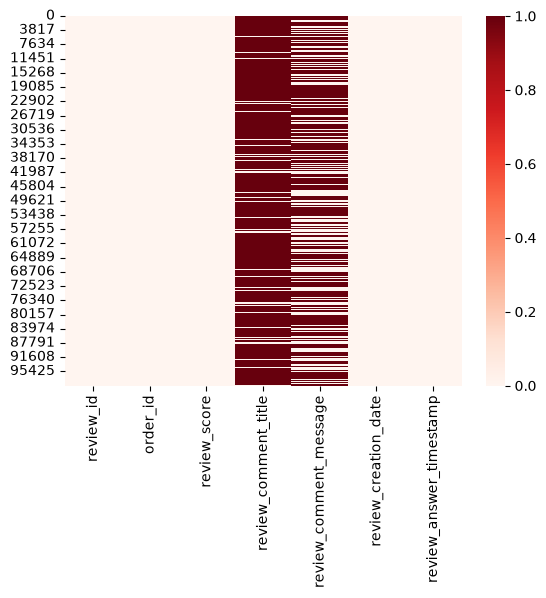

In [206]:
sns.heatmap(order_reviews_df.isna() , cmap="Reds")
plt.show()

In [234]:
order_reviews_df.isna().sum() / len(order_reviews_df) # Proportions de valeurs manquantes

review_id                  0.000000
order_id                   0.000000
review_score               0.000000
review_comment_title       0.883415
review_comment_message     0.587025
review_creation_date       0.000000
review_answer_timestamp    0.000000
dtype: float64

In [235]:
order_reviews_df.duplicated().sum()  # Nous cherchons s'il existe des doublons


np.int64(0)

In [285]:
date_cols = ["review_creation_date", "review_answer_timestamp"]
for var in date_cols :
    order_reviews_df[var] = pd.to_datetime(order_reviews_df[var]  , errors ="coerce")

# Les variables dans date_cols sont transformer en date

In [237]:
(order_reviews_df["review_creation_date"] > order_reviews_df["review_answer_timestamp"]).sum()
# Nous cherchons a savoir s'il existe des incoherence temporelle entre review_creation_date & review_answer_timestamp

np.int64(0)


**Data Quality Checks** effectués sur le dataset  **order_reviews_df**
1. Pas de doublons dans les données 
2. Pas d'incohérences temporelles 
3. Nous avons verifié la qualité des données et identifié des valeurs manquantes qui sont : 
Les variables les plus impactées par des valeurs manquantes sont :
- review_comment_title   avec     88.3415 % de valeur manquantes
- review_comment_message  avec    58.7025 % de valeur manquantes
Ces variables sont des champs de texte libre, et il est normal que les clients ne laissent pas systématiquement un titre ou un commentaire lors de la rédaction d’un avis. Il n’y a donc pas lieu de les imputer.



In [ ]:
order_reviews_df.to_csv(r"..\data\bronze\olist_order_reviews_dataset.csv" , index = False)

In [238]:
products_df =pd.read_csv(r"..\data\bronze\olist_products_dataset.csv")
products_df.head(5)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [239]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB


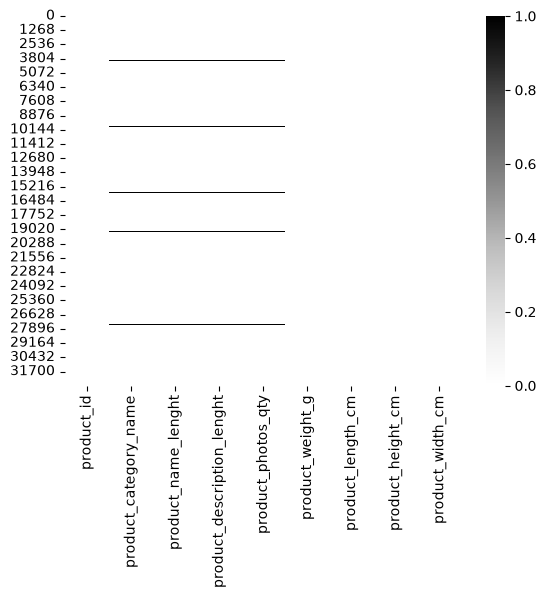

In [240]:
sns.heatmap(products_df.isna() , cmap ="Grays")
plt.show()

In [241]:
products_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [242]:
products_df.duplicated().sum()

np.int64(0)

In [243]:
products_df["product_category_name"].value_counts().sort_index()

product_category_name
agro_industria_e_comercio                           74
alimentos                                           82
alimentos_bebidas                                  104
artes                                               55
artes_e_artesanato                                  19
artigos_de_festas                                   26
artigos_de_natal                                    65
audio                                               58
automotivo                                        1900
bebes                                              919
bebidas                                             81
beleza_saude                                      2444
brinquedos                                        1411
cama_mesa_banho                                   3029
casa_conforto                                      111
casa_conforto_2                                      5
casa_construcao                                    225
cds_dvds_musicais                          

Data Quality Checks effectués sur le dataset  **products_df**
1. Pour les variablles suivantes product_category_name , product_name_lenght , product_description_lenght & product_photos_qty , nous remarquons un pattern de valeurs maquantes , elles sont toutes manquantes en même temps pour un même produit. 
2. pas de doublons dans les données
3. Certaines catégories présentent des noms similaires avec un suffixe _2. En l’absence d’information métier permettant de confirmer leur équivalence, elles sont conservées comme catégories distinctes afin d’éviter une transformation arbitraire

In [ ]:
products_df.to_csv(r"..\data\bronze\olist_products_dataset.csv", index=False)


In [245]:
sellers_df = pd.read_csv(r"..\data\bronze\olist_sellers_dataset.csv")

sellers_df.head(5)


,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,campinas
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,mogi guacu
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,rio de janeiro
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,sao paulo
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,braganca paulista


In [246]:
sellers_df.duplicated().sum()

np.int64(0)

In [247]:
sellers_df["seller_state"].unique()

<ArrowStringArray>
['SP', 'RJ', 'PE', 'PR', 'GO', 'SC', 'BA', 'DF', 'RS', 'MG', 'RN', 'MT', 'CE',
 'PB', 'AC', 'ES', 'RO', 'PI', 'MS', 'SE', 'MA', 'AM', 'PA']
Length: 23, dtype: str

In [248]:
sellers_df['seller_city'].value_counts().sort_index()

seller_city
04482255                                      1
abadia de goias                               1
afonso claudio                                1
aguas claras df                               1
alambari                                      1
alfenas                                       2
almirante tamandare                           1
alvares machado                               1
alvorada                                      1
americana                                    10
amparo                                        5
ampere                                        1
anapolis                                      3
andira-pr                                     1
andradas                                      2
angra dos reis                                1
angra dos reis rj                             1
ao bernardo do campo                          1
aparecida                                     1
aparecida de goiania                          1
aperibe                     

In [249]:
sellers_df["seller_city_clean"] = sellers_df["seller_city"].apply(normalize_city_v2)


In [250]:
city_mapping = {
    "sao paluo": "sao paulo",
    "sao pauo": "sao paulo",
    "sao paulop": "sao paulo",
    "ribeirao pretp": "ribeirao preto",
    "riberao preto": "ribeirao preto",
    "robeirao preto": "ribeirao preto",
    "sando andre": "santo andre",
    "garulhos": "guarulhos",
    "floranopolis": "florianopolis",
    "cascavael": "cascavel",
}

sellers_df["seller_city_clean"] = sellers_df["seller_city_clean"].replace(city_mapping)

sellers_df.loc[
    sellers_df["seller_city_clean"].str.contains("@", na=False), "seller_city_clean"
] = pd.NA

In [251]:
sellers_df.loc[
    sellers_df["seller_city_clean"].str.contains(r"[0-9]", na=False),
    "seller_city_clean",
] = pd.NA


In [252]:
sellers_df["seller_city_clean"].value_counts().sort_index()

seller_city_clean
abadia de goias                               1
afonso claudio                                1
aguas claras df                               1
alambari                                      1
alfenas                                       2
almirante tamandare                           1
alvares machado                               1
alvorada                                      1
americana                                    10
amparo                                        5
ampere                                        1
anapolis                                      3
andira-pr                                     1
andradas                                      2
angra dos reis                                1
angra dos reis rj                             1
ao bernardo do campo                          1
aparecida                                     1
aparecida de goiania                          1
aperibe                                       1
apucarana             

In [253]:
sellers_df["seller_city_clean"] = sellers_df["seller_city_clean"].apply(
    remove_state_suffix
)


In [254]:
city_mapping = {
    "belo horizont": "belo horizonte",
    "mogi das cruses": "mogi das cruzes",
    "sao bernardo do capo": "sao bernardo do campo",
    "sao jose do rio pret": "sao jose do rio preto",
    "sao jose dos pinhas": "sao jose dos pinhais",
    "tabao da serra": "taboao da serra",
    "scao jose do rio pardo": "sao jose do rio pardo",
}

sellers_df["seller_city_clean"] = sellers_df["seller_city_clean"].replace(city_mapping)


Sur l’ensemble de la table `sellers`, les contrôles de qualité ont porté sur l’unicité des vendeurs, les valeurs manquantes et la cohérence des informations géographiques. La colonne `seller_city` présentait plusieurs problèmes de standardisation (accents, espaces, fautes de frappe, suffixes d’État et quelques valeurs invalides), ce qui a conduit à la création de `seller_city_clean`. Un contrôle croisé entre la ville et `seller_state` a également mis en évidence quelques associations géographiques potentiellement incohérentes. Texte collé Les anomalies évidentes ont été corrigées, tandis que les cas ambigus ont été conservés afin d’éviter toute modification non justifiée des données.

In [ ]:
sellers_df.to_csv(r"..\data\bronze\olist_sellers_dataset.csv" , index=False)

In [256]:
cat_df = pd.read_csv(r"..\data\bronze\product_category_name_translation.csv")


In [257]:
cat_df.head(5)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [258]:
cat_df.duplicated().sum()

np.int64(0)

In [259]:
cat_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 3.5 KB


In [260]:
cat_df["product_category_name_english"].value_counts().sort_index()


product_category_name_english
agro_industry_and_commerce                 1
air_conditioning                           1
art                                        1
arts_and_craftmanship                      1
audio                                      1
auto                                       1
baby                                       1
bed_bath_table                             1
books_general_interest                     1
books_imported                             1
books_technical                            1
cds_dvds_musicals                          1
christmas_supplies                         1
cine_photo                                 1
computers                                  1
computers_accessories                      1
consoles_games                             1
construction_tools_construction            1
construction_tools_lights                  1
construction_tools_safety                  1
cool_stuff                                 1
costruction_tools_garden 